# Customer Churn Prediction - Experiment Notebook

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

In [2]:
df = pd.read_csv('../data/customer_churn_dataset-training-master.csv')
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [4]:
df[df.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Remove rows with missing values
df = df.dropna()
# Check the shape of the cleaned DataFrame
print(df.shape)

(440832, 12)


In [6]:
df[df.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn


In [7]:
# Remove customer id
df = df.drop('CustomerID', axis=1)
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [8]:
# Create Age groups by binning the Age column. Include the upper age boundary.
bins = [15, 25, 35, 45, 66]
labels = ['Child', 'Youth', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False, include_lowest=True)
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,AgeGroup
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,Youth
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,Senior
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,Senior
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,Senior
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,Child


## EDA

In [9]:
# Count of Age Groups

df['AgeGroup'].value_counts()

AgeGroup
Senior    156893
Adult     117210
Youth     102693
Child      64036
Name: count, dtype: int64

In [10]:
# Count of Gender

df['Gender'].value_counts()

Gender
Male      250252
Female    190580
Name: count, dtype: int64

In [11]:
# Count of Subscription Type

df['Subscription Type'].value_counts()

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [12]:
# Count of Contract Length

df['Contract Length'].value_counts()

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

In [13]:
# Average Tenure by churn status

df.groupby('Churn')['Tenure'].mean()

Churn
0.0    32.281754
1.0    30.473598
Name: Tenure, dtype: float64

In [14]:
# Average Usage Frequency by churn status

df.groupby('Churn')['Usage Frequency'].mean()

Churn
0.0    16.260552
1.0    15.461658
Name: Usage Frequency, dtype: float64

In [15]:
# Average Age by churn status

df.groupby('Churn')['Age'].mean()

Churn
0.0    36.262973
1.0    41.747263
Name: Age, dtype: float64

In [16]:
# Average Payment delay by churn status

df.groupby('Churn')['Payment Delay'].mean()

Churn
0.0    10.015500
1.0    15.217729
Name: Payment Delay, dtype: float64

In [17]:
# Average Monthly Spend by churn status
df.groupby('Churn')['Total Spend'].mean()

Churn
0.0    749.953111
1.0    541.285528
Name: Total Spend, dtype: float64

In [18]:
# Average Support Calls by churn status
df.groupby('Churn')['Support Calls'].mean()

Churn
0.0    1.586418
1.0    5.144861
Name: Support Calls, dtype: float64

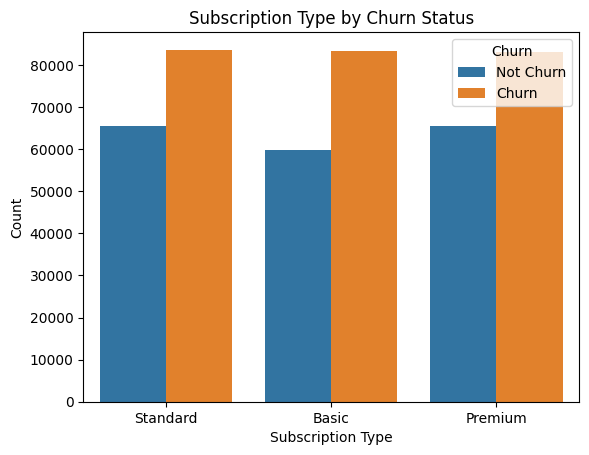

In [19]:
# Show count of Subscription Type by churn status
sns.countplot(x='Subscription Type', hue='Churn', data=df)
plt.title('Subscription Type by Churn Status')
plt.xlabel('Subscription Type')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['Not Churn', 'Churn'])
plt.show()

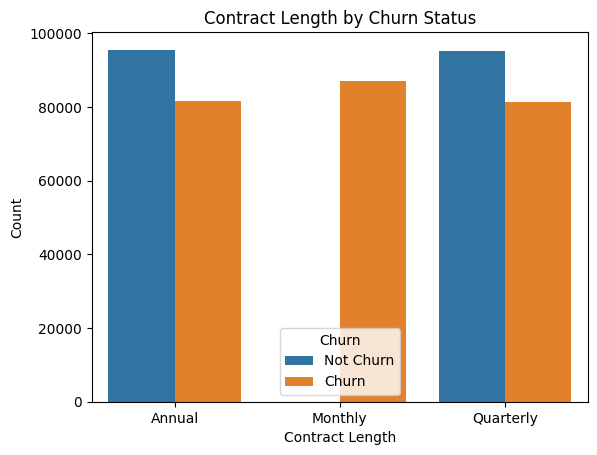

In [20]:
# Show count of churn by contract length
sns.countplot(x='Contract Length', hue='Churn', data=df)
plt.title('Contract Length by Churn Status')
plt.xlabel('Contract Length')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['Not Churn', 'Churn'])
plt.show()

## Data Preprocessing

In [21]:
X = df.drop(['Churn', 'Age'], axis=1)
y = df['Churn'].astype(int)

categorical_features = ['Gender', 'Subscription Type', 'Contract Length', 'AgeGroup']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

## Model Building — Compare 4 Models

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

In [22]:
target_labels = ['Not Churn', 'Churn']

# Dictionary to store models and results
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

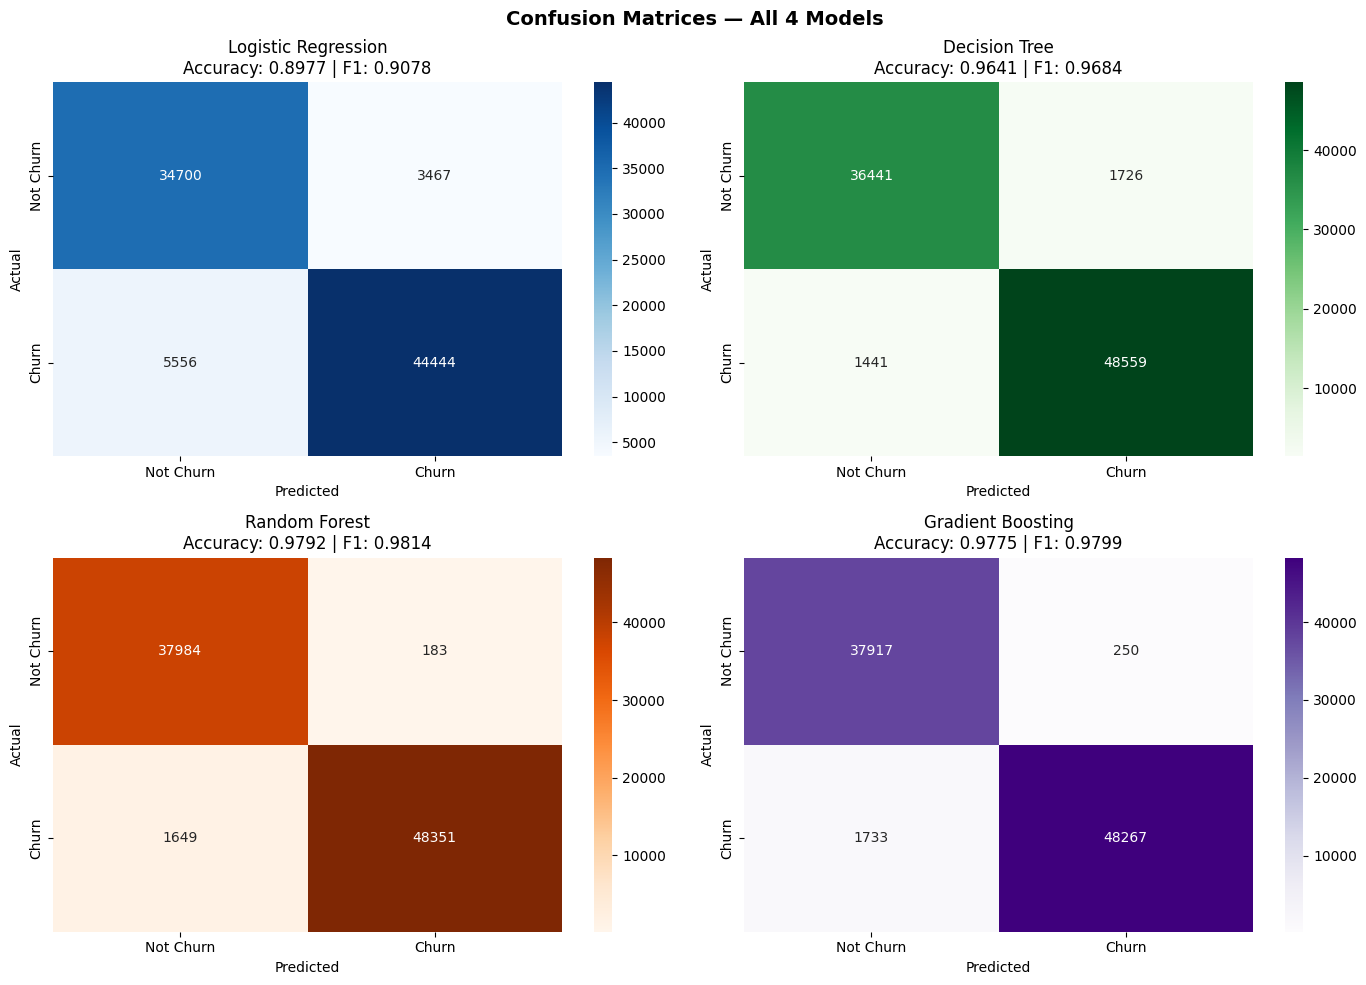

In [23]:
# Train and evaluate all 4 models
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # Train
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'accuracy': acc, 'f1_score': f1, 'model': model, 'y_pred': y_pred}
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i], 
                xticklabels=target_labels, yticklabels=target_labels, ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {acc:.4f} | F1: {f1:.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 4 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Print classification reports for all models
for name, res in results.items():
    print(f'\n{"="*60}')
    print(f'Classification Report — {name}')
    print(f'{"="*60}')
    print(classification_report(y_test, res['y_pred'], target_names=target_labels))


Classification Report — Logistic Regression
              precision    recall  f1-score   support

   Not Churn       0.86      0.91      0.88     38167
       Churn       0.93      0.89      0.91     50000

    accuracy                           0.90     88167
   macro avg       0.89      0.90      0.90     88167
weighted avg       0.90      0.90      0.90     88167


Classification Report — Decision Tree
              precision    recall  f1-score   support

   Not Churn       0.96      0.95      0.96     38167
       Churn       0.97      0.97      0.97     50000

    accuracy                           0.96     88167
   macro avg       0.96      0.96      0.96     88167
weighted avg       0.96      0.96      0.96     88167


Classification Report — Random Forest
              precision    recall  f1-score   support

   Not Churn       0.96      1.00      0.98     38167
       Churn       1.00      0.97      0.98     50000

    accuracy                           0.98     88167
   ma

In [25]:
# Compare models side by side
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1 Score': [r['f1_score'] for r in results.values()],
}).sort_values('F1 Score', ascending=False)

comparison_df

,Model,Accuracy,F1 Score
2,Random Forest,0.979221,0.981407
3,Gradient Boosting,0.977509,0.979871
1,Decision Tree,0.964080,0.968420
0,Logistic Regression,0.897660,0.907845


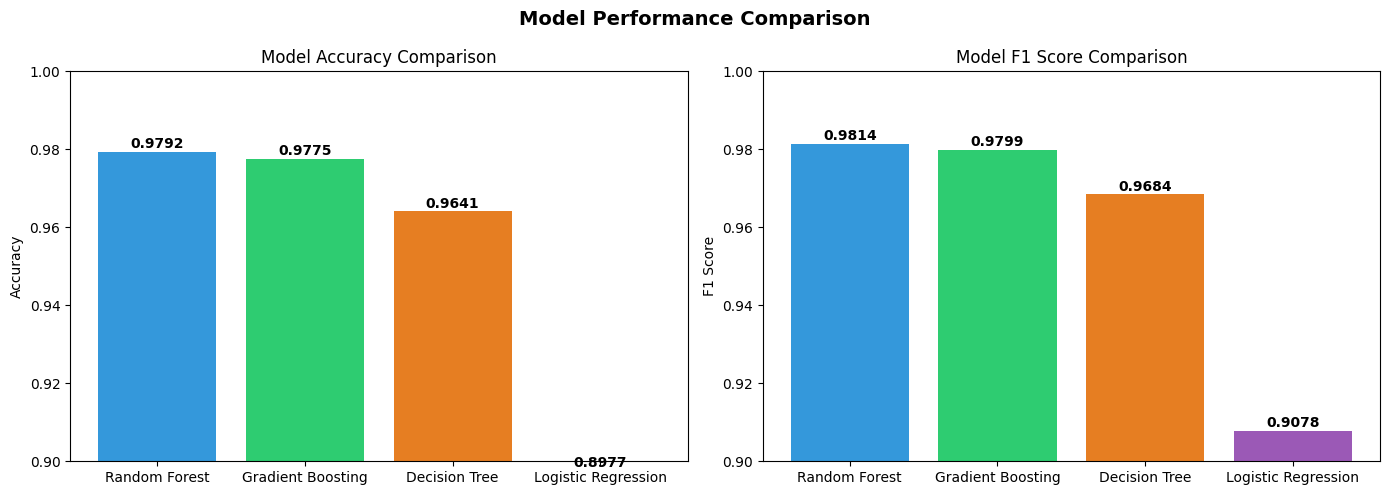

In [26]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

# Accuracy
bars1 = axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=colors)
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.9, 1.0)
for bar, val in zip(bars1, comparison_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                 f'{val:.4f}', ha='center', fontweight='bold')

# F1 Score
bars2 = axes[1].bar(comparison_df['Model'], comparison_df['F1 Score'], color=colors)
axes[1].set_title('Model F1 Score Comparison')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0.9, 1.0)
for bar, val in zip(bars2, comparison_df['F1 Score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Select best model based on F1 Score
best_name = comparison_df.iloc[0]['Model']
best_model = results[best_name]['model']
best_acc = results[best_name]['accuracy']
best_f1 = results[best_name]['f1_score']

print(f"✅ Best Model: {best_name}")
print(f"   Accuracy:  {best_acc:.4f}")
print(f"   F1 Score:  {best_f1:.4f}")

✅ Best Model: Random Forest
   Accuracy:  0.9792
   F1 Score:  0.9814


In [29]:
# Test best model with a custom input
custom_values = ['Female', 42, 22, 3, 3, 'Basic', 'Quarterly', 580.0, 3, 'Adult']

custom_input = pd.DataFrame([custom_values], columns=X.columns)
processed_input = preprocessing_pipeline.transform(custom_input)

prediction = best_model.predict(processed_input)
proba = best_model.predict_proba(processed_input)[0]

print(f"Model: {best_name}")
print(f"Predicted Churn: {int(prediction[0])} ({'Churn' if prediction[0] == 1 else 'Not Churn'})")
print(f"Churn Probability: {proba[1]:.2%}")
print(f"Retention Probability: {proba[0]:.2%}")

Model: Random Forest
Predicted Churn: 0 (Not Churn)
Churn Probability: 0.00%
Retention Probability: 100.00%


C:\Users\DELL\AppData\Local\Temp\ipykernel_11700\3577596659.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=col_importance, x='importance', y='column', palette='viridis')


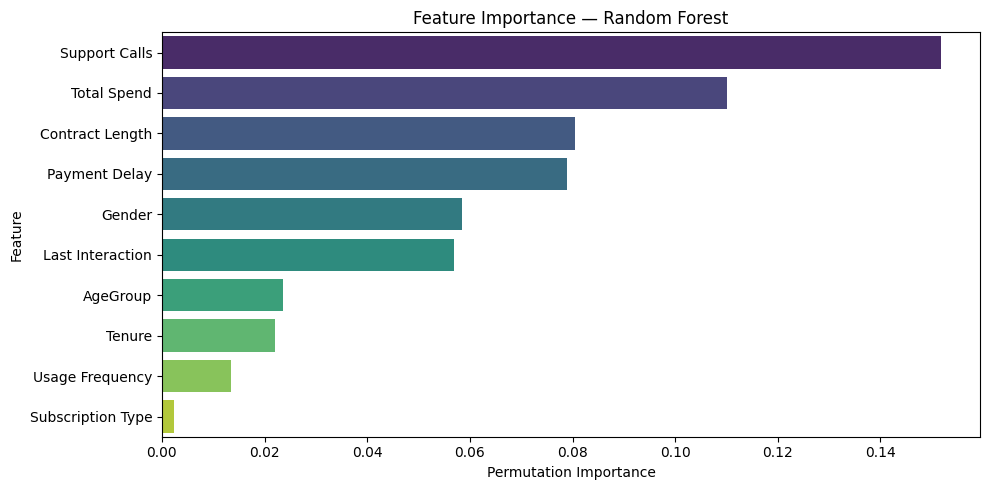

,column,importance
6,Support Calls,0.151803
8,Total Spend,0.110168
1,Contract Length,0.080397
4,Payment Delay,0.078949
2,Gender,0.058548
3,Last Interaction,0.056864
0,AgeGroup,0.023673
7,Tenure,0.022080
9,Usage Frequency,0.013438
5,Subscription Type,0.002310


In [30]:
from sklearn.inspection import permutation_importance

# Permutation importance on best model
perm = permutation_importance(
    best_model,
    X_test_processed,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='f1'
)

feature_names = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()

imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

def original_col(f):
    if f.startswith('num__'):
        return f.replace('num__', '')
    if f.startswith('cat__'):
        x = f.replace('cat__', '')
        return x.split('_')[0]
    return f

col_importance = (
    imp_df.assign(column=imp_df['feature'].map(original_col))
          .groupby('column', as_index=False)['importance']
          .sum()
          .sort_values('importance', ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=col_importance, x='importance', y='column', palette='viridis')
plt.title(f'Feature Importance — {best_name}')
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

col_importance

In [34]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save all 4 models
joblib.dump(models['Logistic Regression'], '../models/logistic_regression_model.joblib')
joblib.dump(models['Decision Tree'], '../models/decision_tree_model.joblib')
joblib.dump(models['Random Forest'], '../models/random_forest_model.joblib')
joblib.dump(models['Gradient Boosting'], '../models/gradient_boosting_model.joblib')

# Save best model separately
joblib.dump(best_model, '../models/best_model.joblib')

# Save preprocessor and column info
joblib.dump(preprocessing_pipeline, '../models/preprocessing_pipeline.joblib')

column_info = {
    'feature_columns': list(X.columns),
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'best_model_name': best_name,
}
joblib.dump(column_info, '../models/column_info.joblib')

print(f"Saved all models and artifacts to ../models/")
print(f"  - logistic_regression_model.joblib")
print(f"  - decision_tree_model.joblib")
print(f"  - random_forest_model.joblib")
print(f"  - gradient_boosting_model.joblib")
print(f"  - best_model.joblib  ← {best_name}")
print(f"  - preprocessing_pipeline.joblib")
print(f"  - column_info.joblib")


Saved all models and artifacts to ../models/
  - logistic_regression_model.joblib
  - decision_tree_model.joblib
  - random_forest_model.joblib
  - gradient_boosting_model.joblib
  - best_model.joblib  ← Random Forest
  - preprocessing_pipeline.joblib
  - column_info.joblib
